#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [215]:
import pandas as pd

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import RobustScaler

from haversine import haversine, Unit
from sklearn.impute import KNNImputer
import math

import warnings

In [216]:
warnings.filterwarnings("ignore")

In [217]:
### carga datos de dataset en dataframe
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [218]:
# Definir los límites geográficos de Nueva York (Manhattan y áreas cercanas)
NY_COORDENADAS = {
    'min_lat': 40.4774,      # Sur de Manhattan
    'max_lat': 40.9176,      # Norte de Manhattan/Bronx
    'min_lon': -74.2591,     # Oeste de Manhattan
    'max_lon': -73.7004      # Este de Brooklyn/Queens
}

In [219]:
def validar_coordenadas(df, bounds=NY_COORDENADAS):
    """
    Valida y filtra coordenadas dentro de los límites de Nueva York
    """
    # Crear máscaras para coordenadas válidas
    valid_pickup = (
        (df['pickup_latitude'] >= bounds['min_lat']) &
        (df['pickup_latitude'] <= bounds['max_lat']) &
        (df['pickup_longitude'] >= bounds['min_lon']) &
        (df['pickup_longitude'] <= bounds['max_lon'])
    )

    valid_dropoff = (
        (df['dropoff_latitude'] >= bounds['min_lat']) &
        (df['dropoff_latitude'] <= bounds['max_lat']) &
        (df['dropoff_longitude'] >= bounds['min_lon']) &
        (df['dropoff_longitude'] <= bounds['max_lon'])
    )

    # Identificar outliers extremos
    extreme_pickup_lat = df[~valid_pickup]['pickup_latitude'].dropna()
    extreme_pickup_lon = df[~valid_pickup]['pickup_longitude'].dropna()

    if len(extreme_pickup_lat) > 0:
        print(f"  • Pickup Latitude - Mín: {extreme_pickup_lat.min():.4f}, Máx: {extreme_pickup_lat.max():.4f}")
    if len(extreme_pickup_lon) > 0:
        print(f"  • Pickup Longitude - Mín: {extreme_pickup_lon.min():.4f}, Máx: {extreme_pickup_lon.max():.4f}")

    extreme_dropoff_lat = df[~valid_dropoff]['dropoff_latitude'].dropna()
    extreme_dropoff_lon = df[~valid_dropoff]['dropoff_longitude'].dropna()

    if len(extreme_dropoff_lat) > 0:
        print(f"  • Dropoff Latitude - Mín: {extreme_dropoff_lat.min():.4f}, Máx: {extreme_dropoff_lat.max():.4f}")
    if len(extreme_dropoff_lon) > 0:
        print(f"  • Dropoff Longitude - Mín: {extreme_dropoff_lon.min():.4f}, Máx: {extreme_dropoff_lon.max():.4f}")

    return valid_pickup, valid_dropoff


In [220]:
def limpiar_coordenadas(df):
    """
    Limpia y filtra las coordenadas de Nueva York
    """
    print("**LIMPIEZA DE COORDENADAS**")

    # Validar coordenadas
    valid_pickup, valid_dropoff = validar_coordenadas(df)

    # Opciones de limpieza
    print(f"\n**OPCIONES DE LIMPIEZA DISPONIBLES:**")
    print("1. Eliminar registros con coordenadas inválidas")
    print("2. Imputar coordenadas inválidas con valores cercanos")
    print("3. Reemplazar coordenadas extremas con la mediana")

    # Aplicar limpieza - OPCIÓN 1: Eliminar registros inválidos (recomendado)
    df_clean = df[valid_pickup & valid_dropoff].copy()

    print(f"\n✅ **RESULTADO DE LA LIMPIEZA (Opción 1 - Eliminar inválidos)**")
    print(f"Registros después de limpieza: {len(df_clean):,}")
    print(f"Porcentaje retenido: {(len(df_clean)/len(df))*100:.1f}%")

    # Calcular distancia de viaje para validación adicional
    from haversine import haversine, Unit

    df_clean['distance_km'] = df_clean.apply(
        lambda row: haversine(
            (row['pickup_latitude'], row['pickup_longitude']),
            (row['dropoff_latitude'], row['dropoff_longitude']),
            unit=Unit.KILOMETERS
        ), axis=1
    )

    # Eliminar viajes con distancia 0 (después del chequeo anterior)
    zero_distance = df_clean['distance_km'] == 0
    if zero_distance.sum() > 0:
        print(f"Viajes con distancia 0 encontrados: {zero_distance.sum()}")
        df_clean = df_clean[~zero_distance]

    return df_clean

In [221]:
def procesar_datos_temporales_y_limpieza(df, test_size=0.2, random_state=42):
    """
    Función integral que realiza:
    1. Procesamiento temporal (día de semana, hora, encoding circular)
    2. División train/test
    3. Limpieza de pasajeros y fares
    4. Creación de características geográficas adicionales
    """

    # 1. COPIA DE SEGURIDAD Y PREPARACIÓN INICIAL
    df_work = df.copy()
    
    # 2. PROCESAMIENTO TEMPORAL - DÍA DE LA SEMANA
    
    # Convertir a datetime (manejar formato UTC)
    df_work['pickup_datetime'] = pd.to_datetime(df_work['pickup_datetime'].str.replace(' UTC', ''), utc=True)
    
    # Extraer día de la semana (0=Lunes, 6=Domingo)
    df_work['day_week_num'] = df_work['pickup_datetime'].dt.dayofweek
    
    # 3. CIRCULAR ENCODING PARA DÍA DE LA SEMANA
    def circular_encoding(df, column, n_categorias, suffix=''):
        """
        Aplica encoding circular (sin y cos) a una columna numérica cíclica
        """
        sin_col = f"{column}_sin{suffix}"
        cos_col = f"{column}_cos{suffix}"
        
        df[sin_col] = np.sin(2 * np.pi * df[column] / n_categorias)
        df[cos_col] = np.cos(2 * np.pi * df[column] / n_categorias)
        
        return df
    
    # Aplicar encoding circular al día de la semana
    df_work = circular_encoding(df_work, 'day_week_num', 7, '')
    
    # 4. PROCESAMIENTO TEMPORAL - HORA DEL DÍA
    
    # Extraer hora
    df_work['hora'] = df_work['pickup_datetime'].dt.hour
    
    # Crear categorías de período del día
    etiquetas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
    bins = [0, 6, 12, 18, 24]
    df_work['period_of_the_day'] = pd.cut(df_work['hora'], bins=bins, 
                                        labels=etiquetas, right=False, include_lowest=True)
    
    # 5. CIRCULAR ENCODING PARA HORA
    df_work = circular_encoding(df_work, 'hora', 24, '')
    
    
    # 9. LIMPIEZA DE OUTLIERS - PASAJEROS
    valid_passengers_mask = df_work['passenger_count'] <= 10
    df_work = df_work[valid_passengers_mask]
    
    # 10. LIMPIEZA DE OUTLIERS - FARE_AMOUNT (<0) 
    valid_fare_mask = df_work['fare_amount'] >= 0
    df_work = df_work[valid_fare_mask]
    
    return df_work

In [222]:
# Aplicar limpieza de coordenadas
df_clean = limpiar_coordenadas(df)

**LIMPIEZA DE COORDENADAS**
  • Pickup Latitude - Mín: -74.0155, Máx: 1644.4215
  • Pickup Longitude - Mín: -1340.6484, Máx: 57.4185
  • Dropoff Latitude - Mín: -881.9855, Máx: 872.6976
  • Dropoff Longitude - Mín: -3356.6663, Máx: 1153.5726

**OPCIONES DE LIMPIEZA DISPONIBLES:**
1. Eliminar registros con coordenadas inválidas
2. Imputar coordenadas inválidas con valores cercanos
3. Reemplazar coordenadas extremas con la mediana

✅ **RESULTADO DE LA LIMPIEZA (Opción 1 - Eliminar inválidos)**
Registros después de limpieza: 195,526
Porcentaje retenido: 97.8%
Viajes con distancia 0 encontrados: 1959


In [223]:
df_clean_temp = procesar_datos_temporales_y_limpieza(df_clean)

In [224]:
df_clean_temp.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,day_week_num,day_week_num_sin,day_week_num_cos,hora,period_of_the_day,hora_sin,hora_cos
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683325,3,0.433884,-0.900969,19,Noche,-0.965926,0.258819
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457593,4,-0.433884,-0.900969,20,Noche,-0.866025,0.500000
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036384,0,0.000000,1.000000,21,Noche,-0.707107,0.707107
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661686,4,-0.433884,-0.900969,8,Mañana,0.866025,-0.500000
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475456,3,0.433884,-0.900969,17,Tarde,-0.965926,-0.258819


In [225]:
df_clean_temp.describe()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,day_week_num,day_week_num_sin,day_week_num_cos,hora,hora_sin,hora_cos
count,1.935500e+05,193550.000000,193550.000000,193550.000000,193550.000000,193550.000000,193550.000000,193550.000000,193550.000000,193550.000000,193550.000000,193550.000000,193550.000000,193550.000000
mean,2.770431e+07,11.299041,-73.975652,40.750837,-73.974720,40.751103,1.683606,3.340741,3.048732,-0.001269,-0.043899,13.487435,-0.194238,-0.069094
std,1.600770e+07,9.464044,0.034196,0.026762,0.033789,0.030568,1.306705,3.558205,1.946914,0.711387,0.701431,6.515608,0.668676,0.714405
min,1.000000e+00,0.000000,-74.243432,40.498988,-74.257692,40.486242,0.000000,0.000084,0.000000,-0.974928,-0.900969,0.000000,-1.000000,-1.000000
25%,1.382238e+07,6.000000,-73.992287,40.736498,-73.991605,40.735372,1.000000,1.280475,1.000000,-0.781831,-0.900969,9.000000,-0.866025,-0.707107
50%,2.773388e+07,8.500000,-73.982140,40.753314,-73.980591,40.753752,1.000000,2.179170,3.000000,0.000000,-0.222521,14.000000,-0.258819,-0.258819
75%,4.153345e+07,12.500000,-73.968529,40.767528,-73.965630,40.768318,2.000000,3.933712,5.000000,0.781831,0.623490,19.000000,0.500000,0.707107
max,5.542357e+07,499.000000,-73.702735,40.917048,-73.700650,40.916956,6.000000,35.341909,6.000000,0.974928,1.000000,23.000000,1.000000,1.000000


In [249]:
x = df_clean_temp.drop('fare_amount', axis=1)
y = df_clean_temp['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

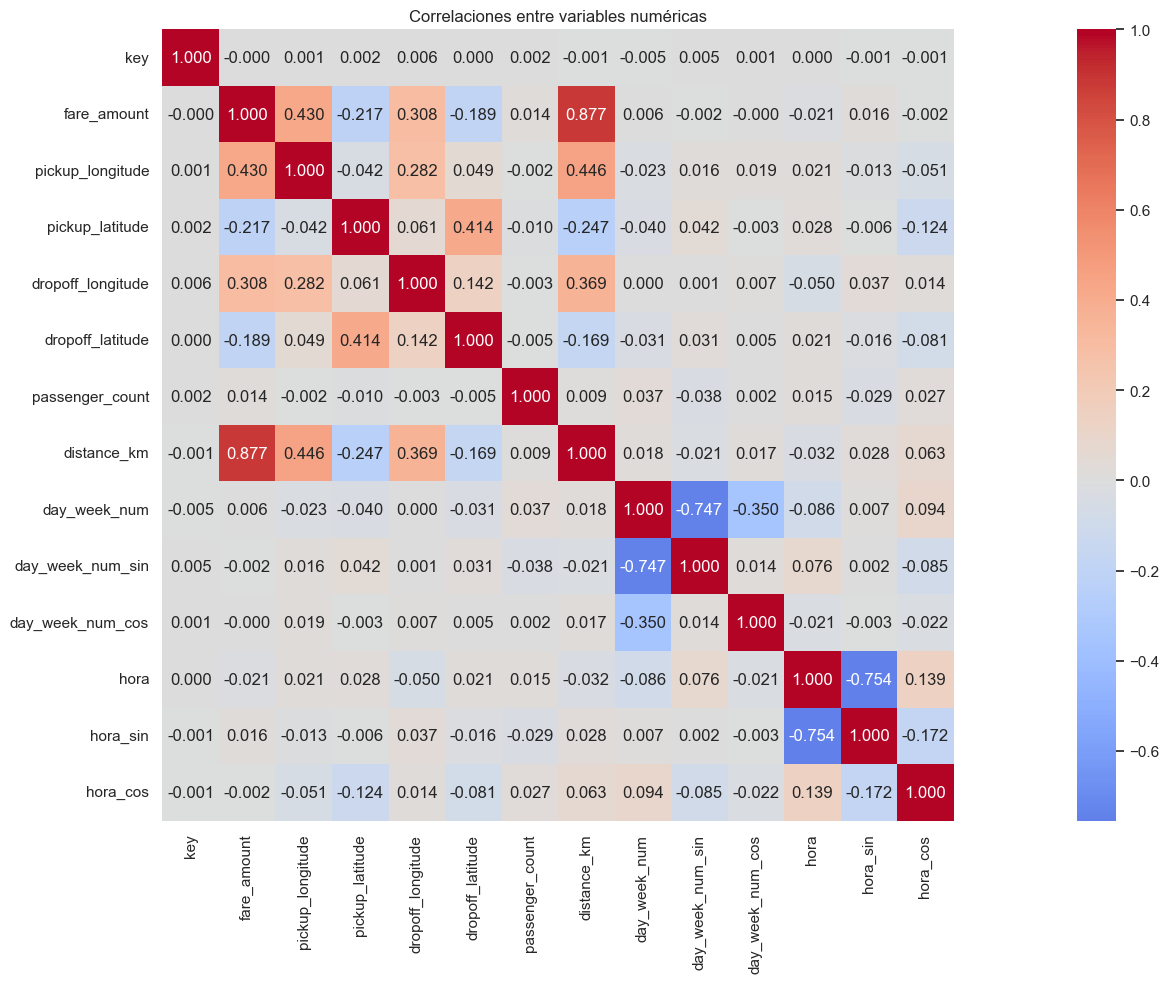

In [254]:
# Seleccionar solo columnas numéricas para la matriz de correlación
numeric_cols = df_clean_temp.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

# Visualización de correlaciones
plt.figure(figsize=(25, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Correlaciones entre variables numéricas')
plt.tight_layout()
plt.show()

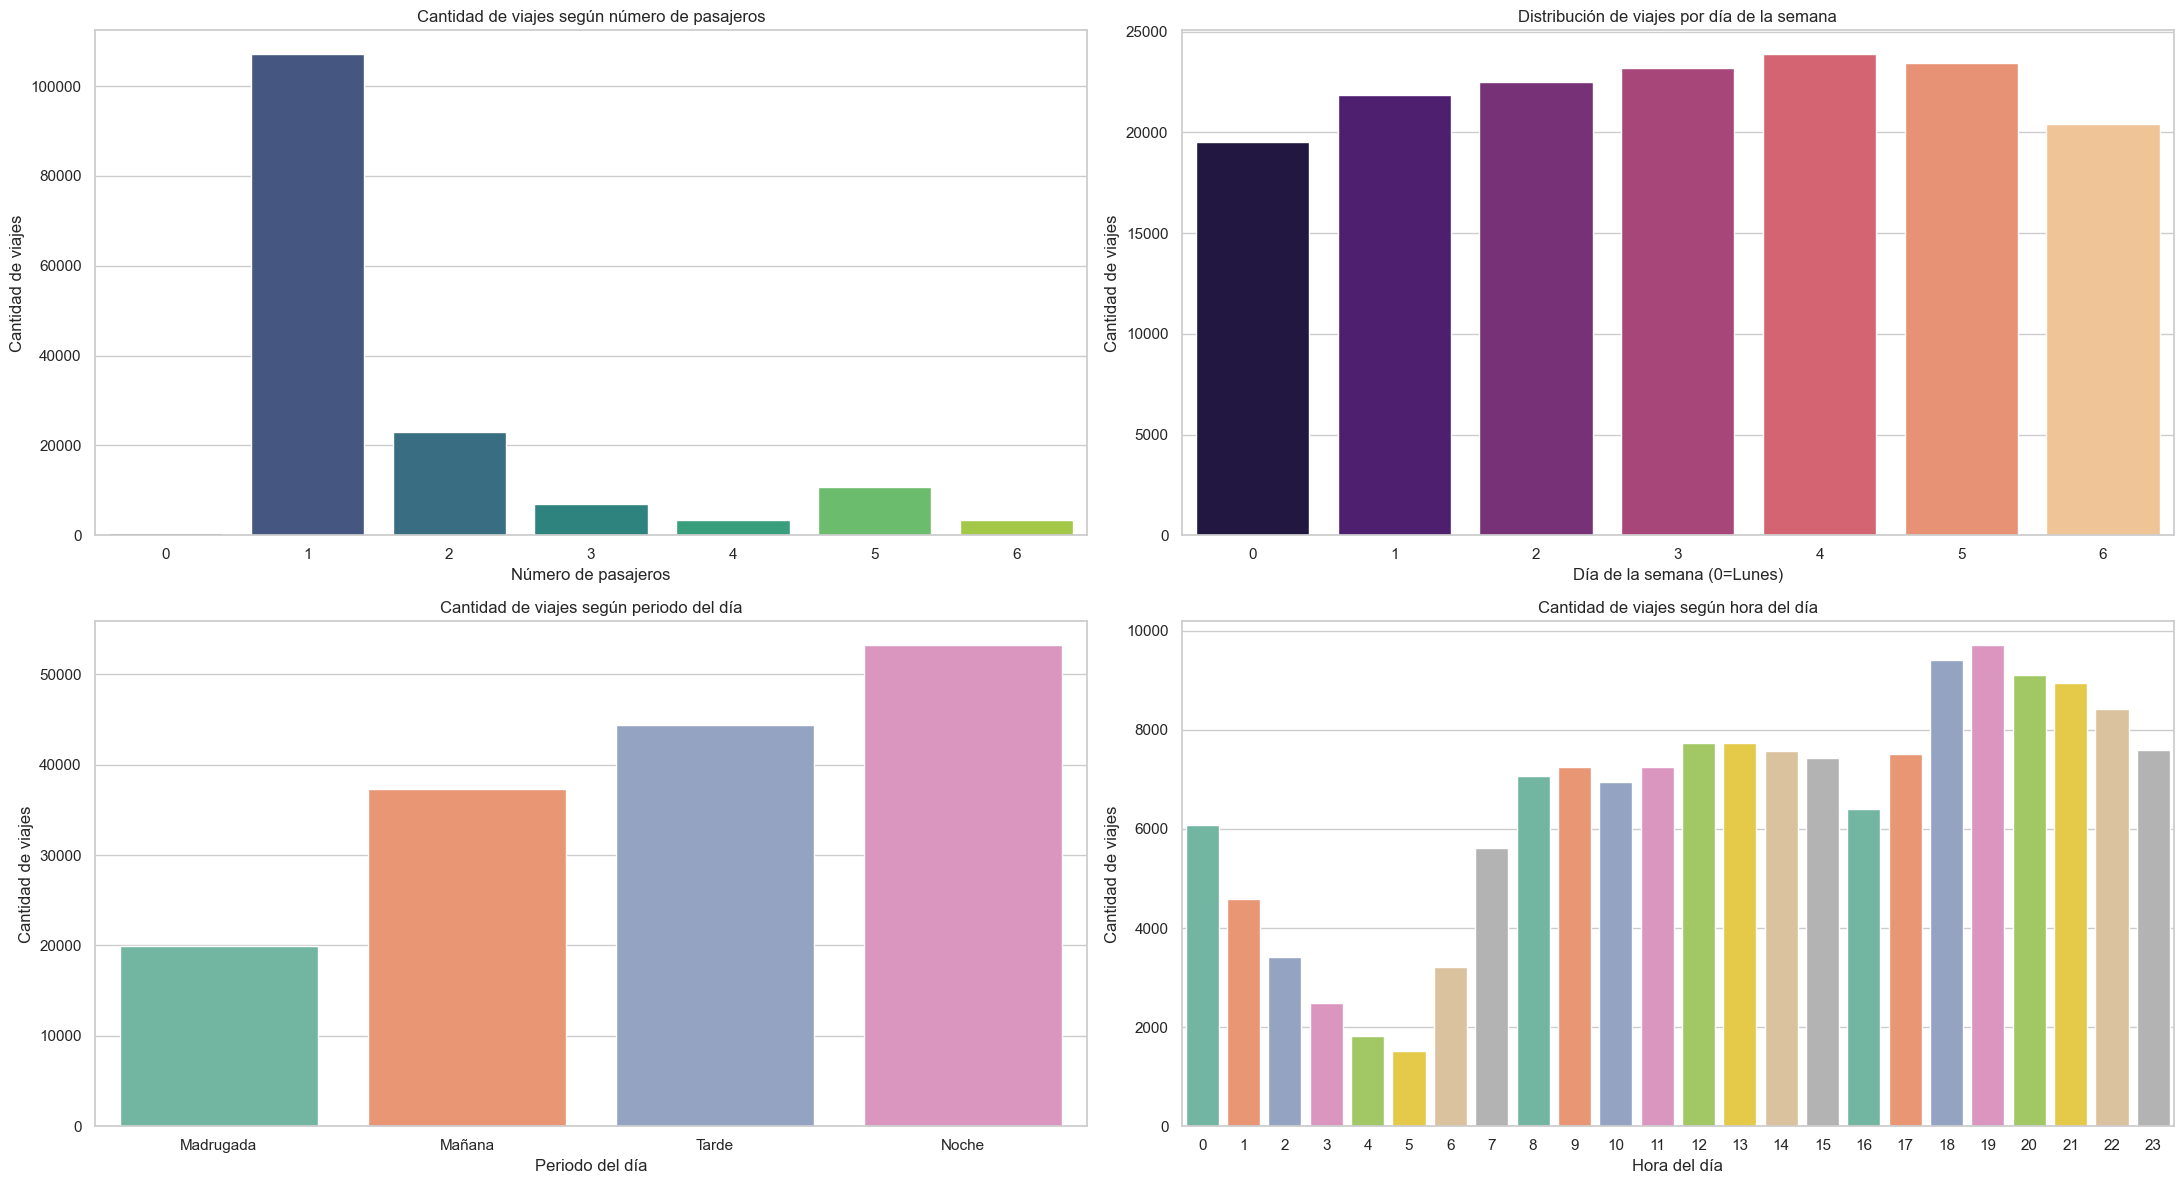

In [228]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# Conteo de viajes por cantidad de pasajeros
sns.countplot(data=X_train, x="passenger_count", ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Cantidad de viajes según número de pasajeros")
axes[0,0].set_xlabel("Número de pasajeros")
axes[0,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por día de la semana
order_days = [0, 1, 2, 3, 4, 5, 6]  # Lunes=0 ... Domingo=6
sns.countplot(data=X_train, x="day_week_num", order=order_days, ax=axes[0,1], palette="magma")
axes[0,1].set_title("Distribución de viajes por día de la semana")
axes[0,1].set_xlabel("Día de la semana (0=Lunes)")
axes[0,1].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="period_of_the_day",
    order=["Madrugada", "Mañana", "Tarde", "Noche"],
    ax=axes[1,0],
    palette="Set2"
)
axes[1,0].set_title("Cantidad de viajes según periodo del día")
axes[1,0].set_xlabel("Periodo del día")
axes[1,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="hora",
    ax=axes[1,1],
    palette="Set2"
)
axes[1,1].set_title("Cantidad de viajes según hora del día")
axes[1,1].set_xlabel("Hora del día")
axes[1,1].set_ylabel("Cantidad de viajes")


plt.tight_layout()
plt.show()

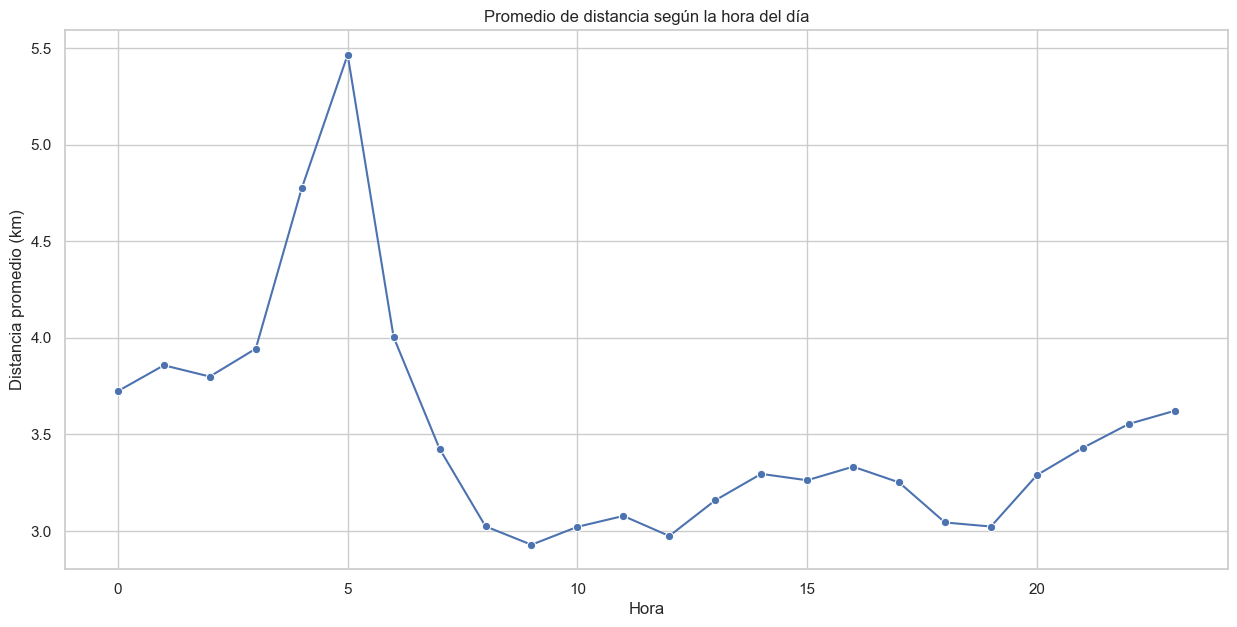

In [229]:
# Promedio de distancia según hora del día

plt.figure(figsize=(15,7))
sns.lineplot(data=X_train, x="hora", y="distance_km", estimator="mean", ci=None, marker="o")
plt.title("Promedio de distancia según la hora del día")
plt.xlabel("Hora")
plt.ylabel("Distancia promedio (km)")
plt.show()

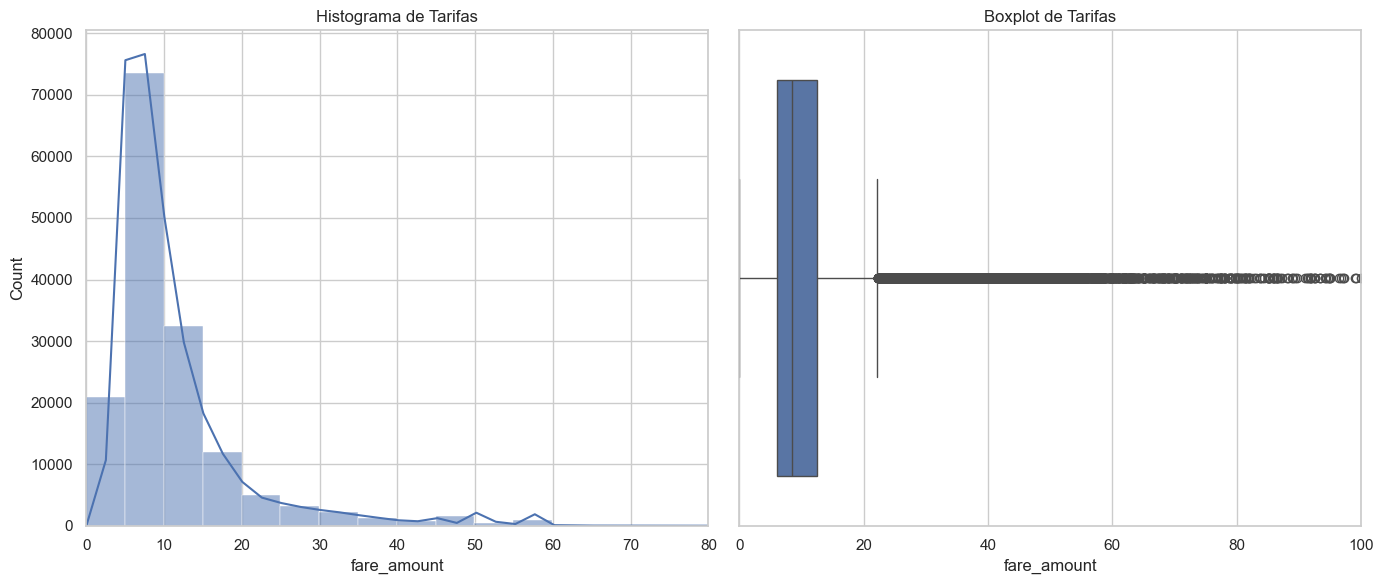

In [230]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma de tarifas
sns.histplot(y_train, bins=100, kde=True, ax=axes[0])
axes[0].set_xlim(0, 80)  # límite para ver mejor la zona central
axes[0].set_title("Histograma de Tarifas")

# Boxplot de tarifas
sns.boxplot(x=y_train, ax=axes[1])
axes[1].set_xlim(0, 100)
axes[1].set_title("Boxplot de Tarifas")

plt.tight_layout()
plt.show()

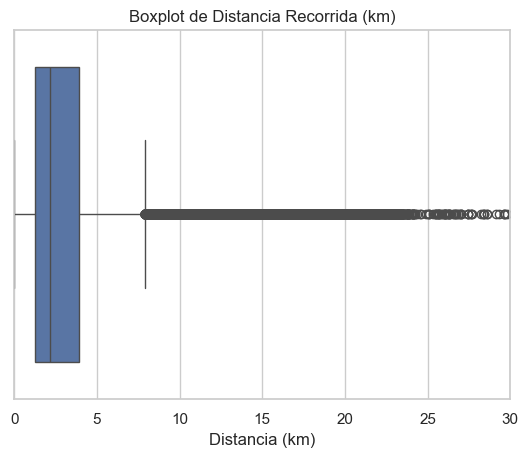

In [231]:
# Boxplot distancia
sns.boxplot(x=X_train['distance_km'])
plt.title("Boxplot de Distancia Recorrida (km)")
plt.xlabel("Distancia (km)")
plt.xlim(0, 30) 
plt.show()

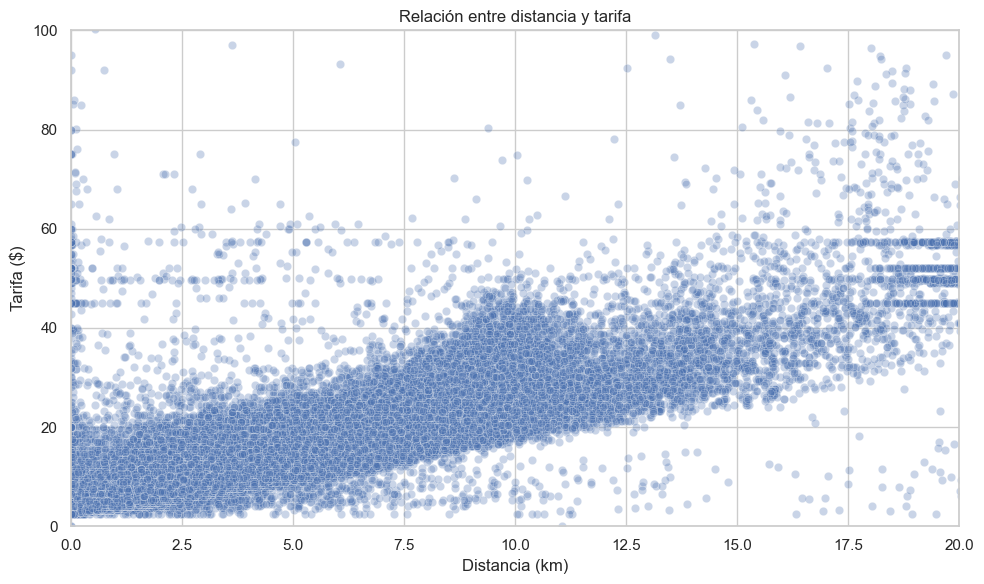

In [232]:
# Relación entre distancia y tarifa (dispersión)
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x=X_train["distance_km"], y=y_train, alpha=0.3)
plt.xlim(0, 20)   # Limitar a 20 km para evitar outliers extremos
plt.ylim(0, 100)  # Limitar a 100 dólares para evitar outliers extremos
plt.title("Relación entre distancia y tarifa")
plt.xlabel("Distancia (km)")
plt.ylabel("Tarifa ($)")
plt.tight_layout()
plt.show()

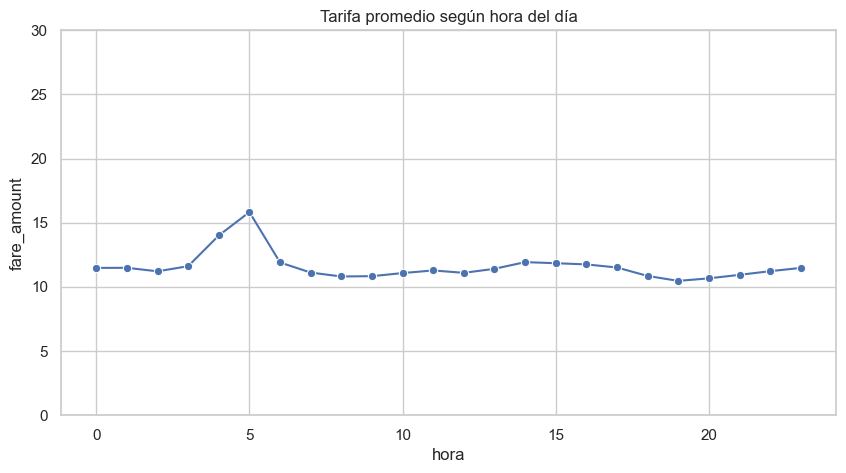

In [233]:
# Fare por hora del día

plt.figure(figsize=(10,5))
sns.lineplot(x=X_train["hora"], y=y_train, estimator="mean", errorbar=None, marker="o")
plt.ylim(0, 30)
plt.title("Tarifa promedio según hora del día")
plt.show()

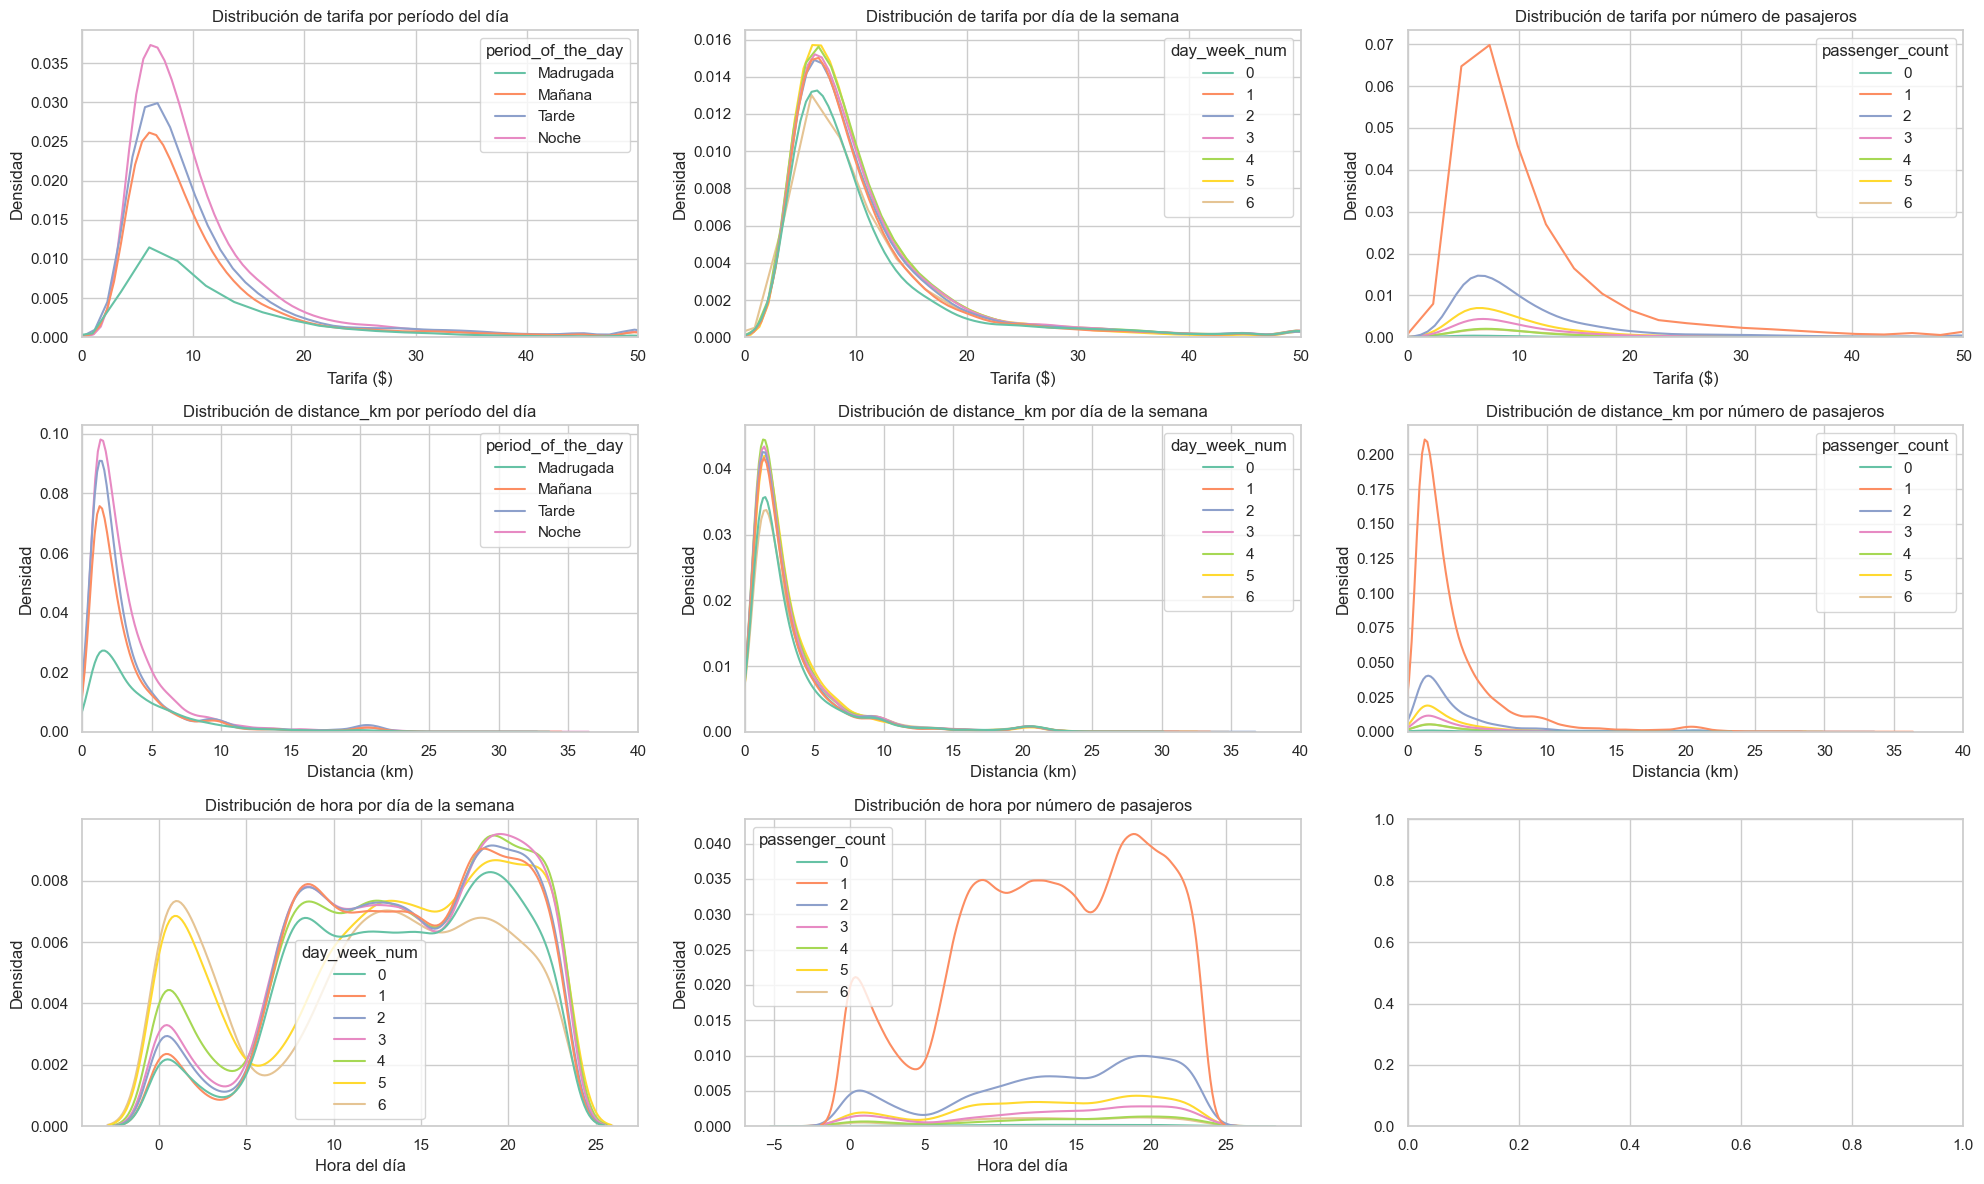

In [234]:
fig, ((ax1, ax2, ax3) ,(ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))

# Combinar X_train y y_train para los gráficos de target
data_combined = X_train.copy()
data_combined['target'] = y_train

# Gráfico 1: Distribución de la variable objetivo por período del día
sns.kdeplot(data=data_combined, x='target', hue='period_of_the_day', palette='Set2', ax=ax1)
ax1.set_xlim(0, 50)
ax1.set_title("Distribución de tarifa por período del día")
ax1.set_xlabel("Tarifa ($)")
ax1.set_ylabel("Densidad")

# Gráfico 2: Distribución de la variable objetivo por día de la semana
sns.kdeplot(data=data_combined, x='target', hue='day_week_num', palette='Set2', ax=ax2)
ax2.set_xlim(0, 50)
ax2.set_title("Distribución de tarifa por día de la semana")
ax2.set_xlabel("Tarifa ($)")
ax2.set_ylabel("Densidad")

# Gráfico 3: Distribución de la variable objetivo por número de pasajeros
sns.kdeplot(data=data_combined, x='target', hue='passenger_count', palette='Set2', ax=ax3)
ax3.set_xlim(0, 50)
ax3.set_title("Distribución de tarifa por número de pasajeros")
ax3.set_xlabel("Tarifa ($)")
ax3.set_ylabel("Densidad")

# Gráfico 4: Distribución de distance_km por período del día
sns.kdeplot(data=X_train, x='distance_km', hue='period_of_the_day', palette='Set2', ax=ax4)
ax4.set_xlim(0, 40)
ax4.set_title("Distribución de distance_km por período del día")
ax4.set_xlabel("Distancia (km)")
ax4.set_ylabel("Densidad")

# Gráfico 5: Distribución de distance_km por día de la semana
sns.kdeplot(data=X_train, x='distance_km', hue='day_week_num', palette='Set2', ax=ax5)
ax5.set_xlim(0, 40)
ax5.set_title("Distribución de distance_km por día de la semana")
ax5.set_xlabel("Distancia (km)")
ax5.set_ylabel("Densidad")

# Gráfico 6: Distribución de distance_km por número de pasajeros
sns.kdeplot(data=X_train, x='distance_km', hue='passenger_count', palette='Set2', ax=ax6)
ax6.set_xlim(0, 40)
ax6.set_title("Distribución de distance_km por número de pasajeros")
ax6.set_xlabel("Distancia (km)")
ax6.set_ylabel("Densidad")

# Gráfico 7: Distribución de hora por día de la semana
sns.kdeplot(data=X_train, x='hora', hue='day_week_num', palette='Set2', ax=ax7)
ax7.set_title("Distribución de hora por día de la semana")
ax7.set_xlabel("Hora del día")
ax7.set_ylabel("Densidad")

# Gráfico 8: Distribución de hora por número de pasajeros
sns.kdeplot(data=X_train, x='hora', hue='passenger_count', palette='Set2', ax=ax8)
ax8.set_title("Distribución de hora por número de pasajeros")
ax8.set_xlabel("Hora del día")
ax8.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

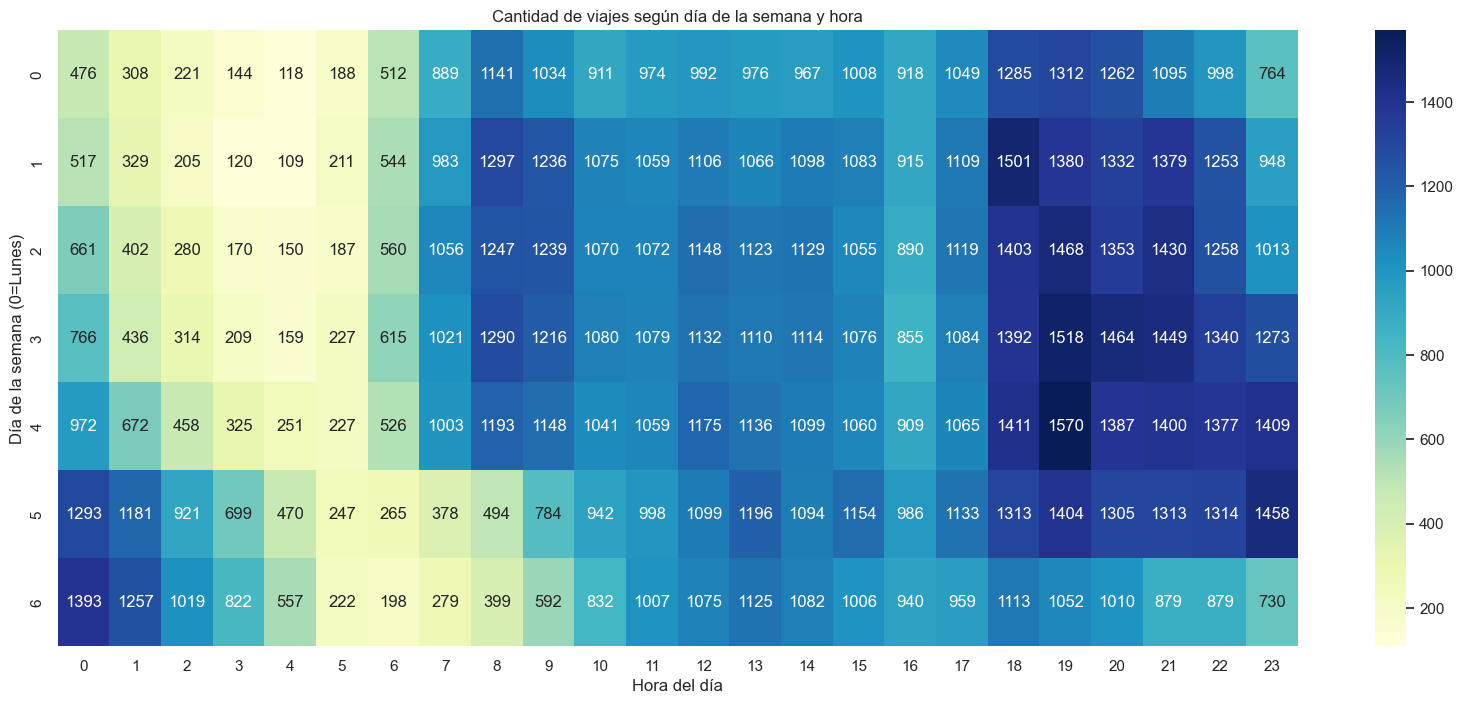

In [235]:
# Heatmap hora vs día de la semana

pivot_data = X_train.groupby(['day_week_num','hora']).size().unstack(fill_value=0)
plt.figure(figsize=(20,8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Cantidad de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

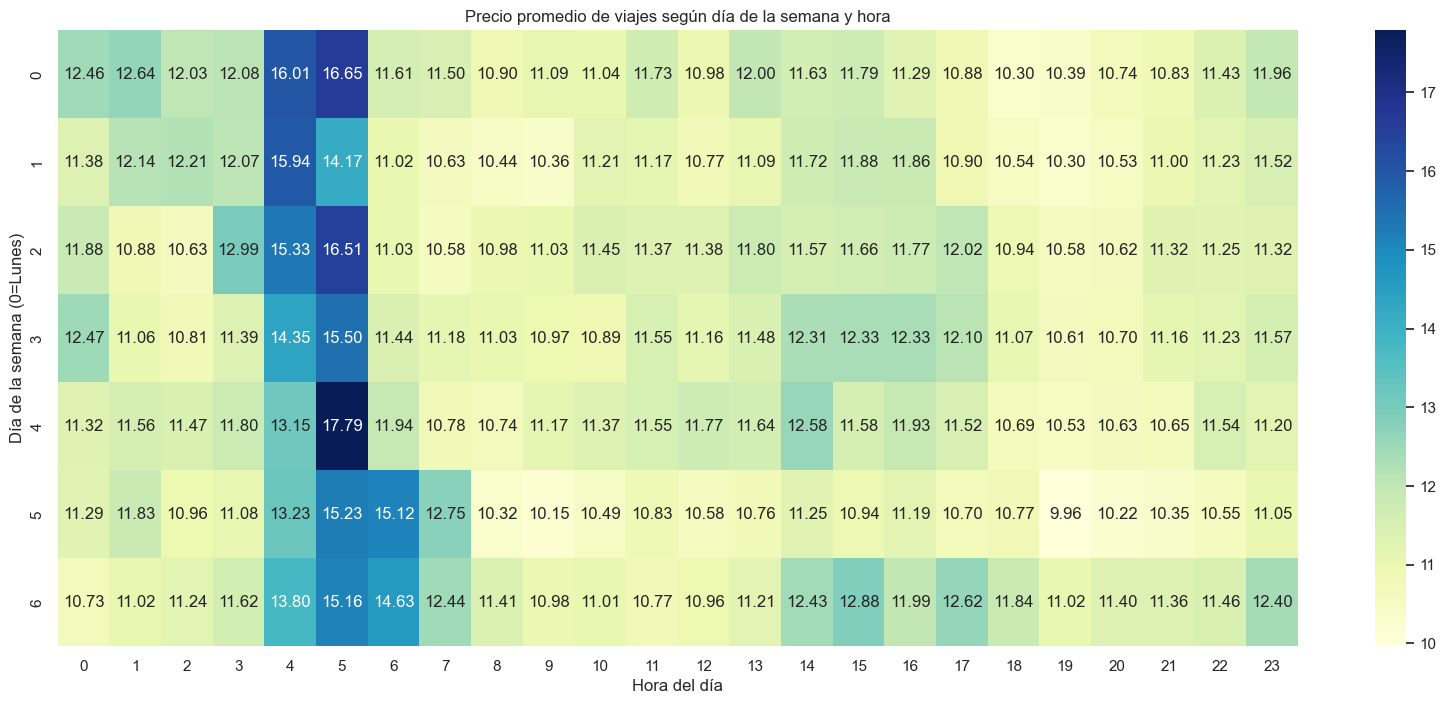

In [236]:
# Heatmap precio promedio vs día de la semana y hora

# Combinar X_train y y_train
data_combined = X_train[['day_week_num', 'hora']].copy()
data_combined['target'] = y_train

# Agrupar por día de la semana y hora, y calcular el precio promedio
pivot_data = data_combined.groupby(['day_week_num', 'hora'])['target'].mean().unstack(fill_value=0)

plt.figure(figsize=(20, 8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Precio promedio de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

In [237]:
X_train.isna().sum()

key                  0
date                 0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
distance_km          0
day_week_num         0
day_week_num_sin     0
day_week_num_cos     0
hora                 0
period_of_the_day    0
hora_sin             0
hora_cos             0
dtype: int64

In [238]:
X_train = X_train.drop('date', axis=1)
X_test = X_test.drop('date', axis=1)
X_train = X_train.drop('pickup_datetime', axis=1)
X_test = X_test.drop('pickup_datetime', axis=1)
X_train = X_train.drop('period_of_the_day', axis=1)
X_test = X_test.drop('period_of_the_day', axis=1)

In [239]:
# Escalado robusto para características numéricas
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [240]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [241]:
# Predicciones sobre el conjunto de entrenamiento
y_pred_train = model_lr.predict(X_train_scaled)

# Métricas
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = math.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

print("Métricas en el conjunto de entrenamiento:")
print(f'Error Cuadrático Medio: {round(mse_train, 3)}')
print(f'Raíz Error Cuadrático Medi: {round(rmse_train, 3)}')
print(f'Coeficiente de Determinación: {round(r2_train, 3)}')

Métricas en el conjunto de entrenamiento:
Error Cuadrático Medio: 20.287
Raíz Error Cuadrático Medi: 4.504
Coeficiente de Determinación: 0.774


In [242]:
# Predicciones sobre el conjunto de test
y_pred = model_lr.predict(X_test_scaled)

# Métricas
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = math.sqrt(mse_test) # mean_squared_error(y_test_op1, y_pred_op1, squared=False)
r2_test = r2_score(y_test, y_pred)

print("\nMétricas en el conjunto de testeo:")
print(f'Error Cuadrático Medio: {round(mse_test, 3)}')
print(f'Raíz Error Cuadrático Medio: {round(rmse_test, 3)}')
print(f'Coeficiente de Determinación: {round(r2_test, 3)}')


Métricas en el conjunto de testeo:
Error Cuadrático Medio: 18.229
Raíz Error Cuadrático Medio: 4.269
Coeficiente de Determinación: 0.794


In [244]:
# Coeficientes de la recta de regresión
intercepto = model_lr.intercept_
print(f"Intercepto: {intercepto}")
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train.columns,
                         'coef': model_lr.coef_.flatten()}
                  )

df_coeficientes[df_coeficientes.coef != 0]

Intercepto: 8.706676101178392


,predictor,coef
0,key,0.003882
1,pickup_longitude,0.346987
2,pickup_latitude,0.130313
3,dropoff_longitude,-0.108042
4,dropoff_latitude,-0.542262
5,passenger_count,0.057664
6,distance_km,6.063443
7,day_week_num,-0.066508
8,day_week_num_sin,0.223341
9,day_week_num_cos,-0.379430


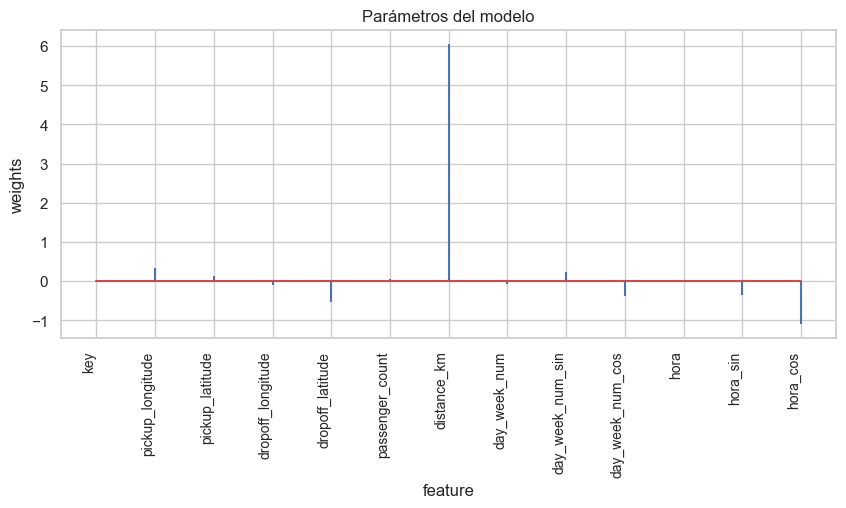

In [246]:
# Coeficientes del modelo

df_coeficientes = pd.DataFrame({'predictor': X_train.columns, 'coef': df_coeficientes.coef})

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('weights')
ax.set_title('Parámetros del modelo')
plt.show()

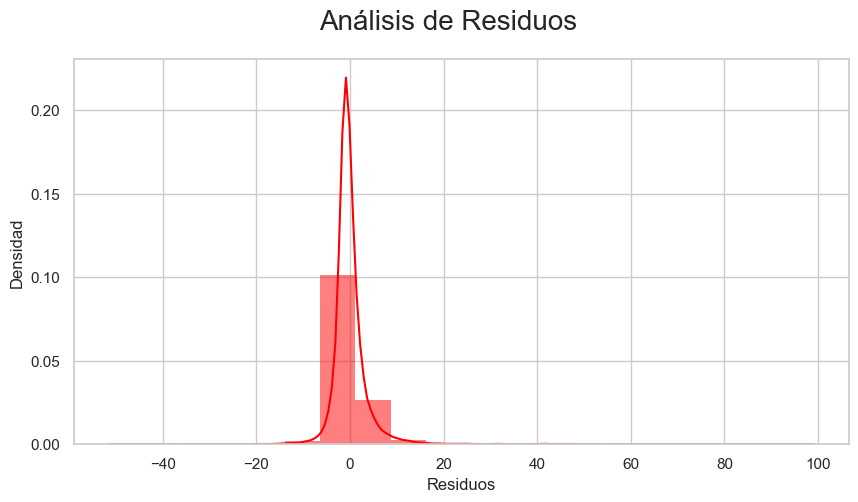

In [247]:
# Análisis de Residuos
fig = plt.figure(figsize=(10,5))

sns.histplot((y_test - y_pred), color="red", kde=True, stat="density", linewidth=0, bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)
plt.xlabel('Residuos')
plt.ylabel('Densidad')
plt.show()

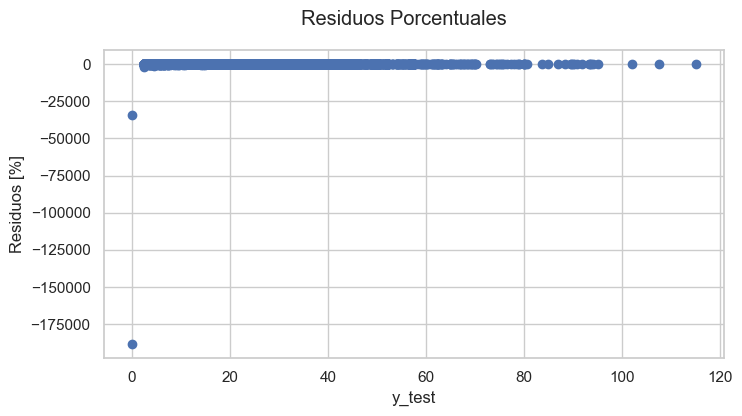

In [248]:
fig = plt.figure(figsize=(8,4))
fig.suptitle('Residuos Porcentuales')
plt.xlabel('y_test')
plt.ylabel('Residuos [%]')
plt.scatter(y_test,100*(y_test-y_pred)/y_test)
plt.show()